In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    classification_report, roc_auc_score, f1_score
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Online Shoppers Purchasing Intent Prediction

## Project Overview
This project predicts whether a website visitor will make a purchase based on behavioral and session data. 

## Tech Stack
* **Data Processing:** Pandas, NumPy, Scikit-Learn
* **Modeling:** Logistic Regression, Random Forest, Gradient Boosting, XGBoost
* **Optimization:** RandomizedSearchCV, StratifiedKFold
* **Evaluation:** ROC-AUC, Recall, Precision, F1-Score, Confusion Matrix

#### Dataset = https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset  

In [2]:
path = Path('online_shoppers_intention.csv') #importing dataset 
df = pd.read_csv(path) #turning into a data frame 
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


#### EDA (Exploratory Data Analysis)

In [3]:
df.duplicated().sum() #125 duplicates

np.int64(125)

In [4]:
#I will drop duplicates since it is very small ammount and would rather have a simple little data than a large complex one. 

df = df.drop_duplicates()

In [5]:
df.isnull().sum() #Great no nun values! 

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [7]:
df.apply(lambda col: col.unique())

Administrative             [0, 1, 2, 4, 12, 3, 10, 6, 5, 9, 8, 16, 13, 11...
Administrative_Duration    [0.0, 53.0, 64.6, 6.0, 18.0, 9.0, 56.0, 16.0, ...
Informational              [0, 1, 2, 4, 16, 5, 3, 14, 6, 12, 7, 9, 10, 8,...
Informational_Duration     [0.0, 120.0, 16.0, 94.0, 93.0, 75.0, 19.0, 22....
ProductRelated             [1, 2, 10, 19, 0, 3, 16, 7, 6, 23, 13, 20, 8, ...
ProductRelated_Duration    [0.0, 64.0, 2.666666667, 627.5, 154.2166667, 3...
BounceRates                [0.2, 0.0, 0.05, 0.02, 0.015789474, 0.01875, 0...
ExitRates                  [0.2, 0.1, 0.14, 0.05, 0.024561404, 0.02222222...
PageValues                 [0.0, 54.17976426, 19.44707913, 38.30849268, 2...
SpecialDay                                    [0.0, 0.4, 0.8, 1.0, 0.2, 0.6]
Month                      [Feb, Mar, May, Oct, June, Jul, Aug, Nov, Sep,...
OperatingSystems                                    [1, 2, 4, 3, 7, 6, 8, 5]
Browser                          [1, 2, 3, 4, 5, 6, 7, 10, 8, 9, 12, 13, 11]

In [ ]:
# Convert binary columns to numeric values.
df['Revenue'] = df['Revenue'].map({True: 1, False: 0})
df['Weekend'] = df['Weekend'].map({True: 1, False : 0})
month_map = {
    'Jan':1, 
    'Feb': 2, 'Mar': 3,
    'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['Month'] = df['Month'].map(month_map)

In [ ]:
# VisitorType is categorical, so I will one-hot encode it in a deterministic way.

categorical_columns = ['VisitorType']

for column in categorical_columns:
    for value in sorted(df[column].dropna().unique()):
        df[value] = (df[column] == value).astype(int)

df = df.drop(columns=categorical_columns)

In [10]:
df.isnull().sum() #Now we have some new missing values we will handle. 

Administrative               0
Administrative_Duration      0
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                    0
PageValues                   0
SpecialDay                   0
Month                      285
OperatingSystems             0
Browser                      0
Region                       0
TrafficType                  0
Weekend                      0
Revenue                      0
New_Visitor                  0
Other                        0
Returning_Visitor            0
dtype: int64

In [11]:
# Handle missing values.
df = df.dropna(subset=['Revenue'])  # Never impute the target column.
df = df.dropna(subset = ['Month'])

Text(0.5, 1.0, 'Weekend Revenue')

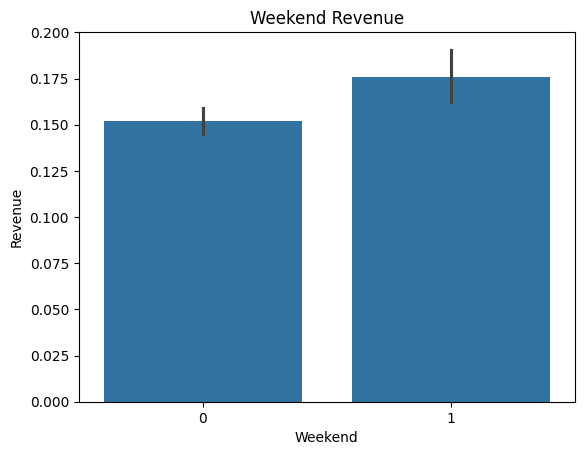

In [12]:
sns.barplot(x="Weekend", y="Revenue", data=df)
plt.title('Weekend Revenue')

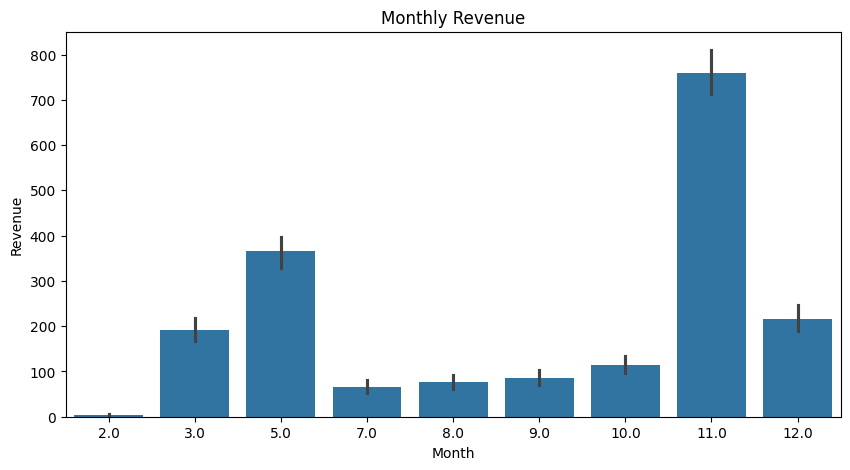

In [13]:
#Monthly revenue
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Month',
    y='Revenue',
    estimator=sum
)

plt.title('Monthly Revenue')
plt.show()

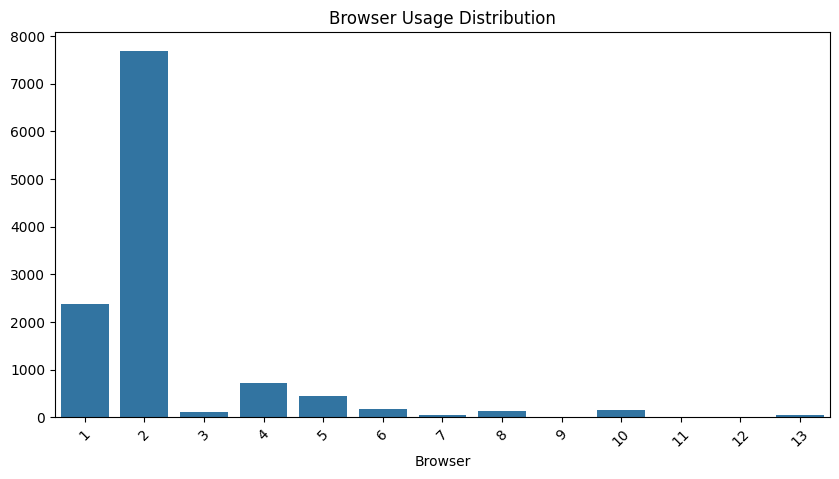

In [14]:
browser_counts = df['Browser'].value_counts()
plt.figure(figsize=(10,5))

sns.barplot(
    x=browser_counts.index,
    y=browser_counts.values
)

plt.xticks(rotation=45)
plt.title("Browser Usage Distribution")
plt.show()

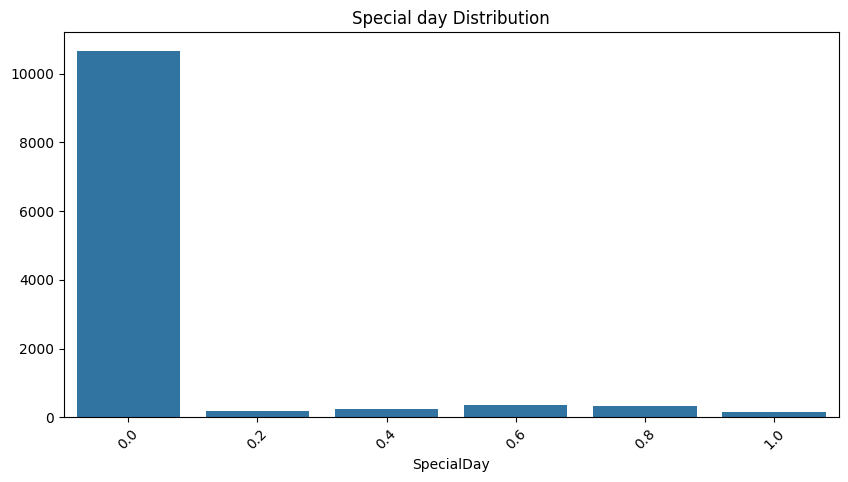

In [15]:
special_day = df['SpecialDay'].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=special_day.index,
    y=special_day.values
)

plt.xticks(rotation=45)
plt.title("Special day Distribution")
plt.show()

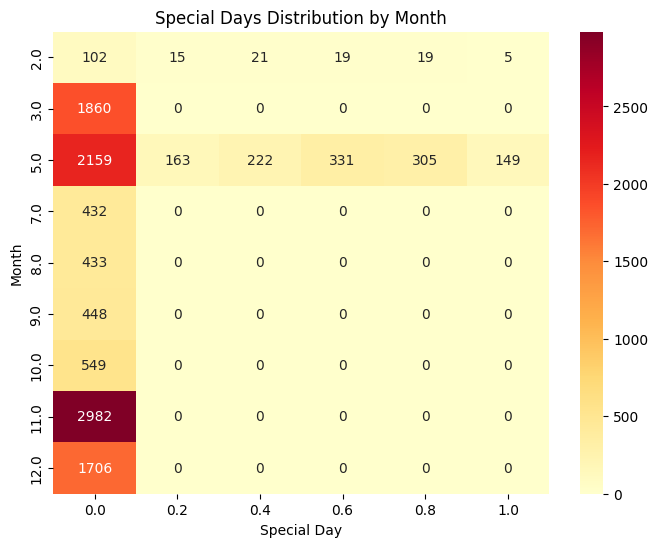

In [16]:
#Lets plot a heatmap witch special day month distribution

heat_data = pd.crosstab(df['Month'], df['SpecialDay'])
plt.figure(figsize=(8,6))

sns.heatmap(
    heat_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

plt.title('Special Days Distribution by Month')
plt.xlabel('Special Day')
plt.ylabel('Month')

plt.show()

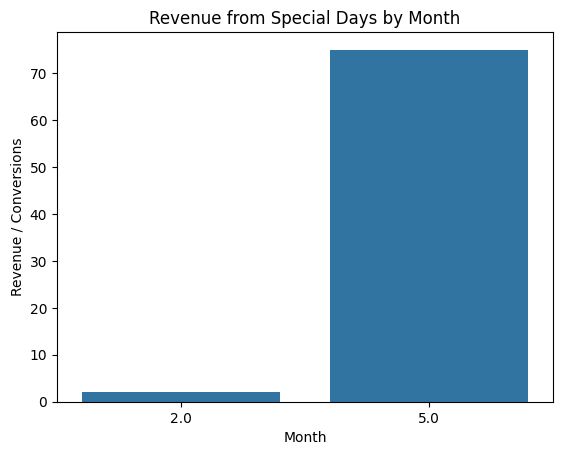

Special days do not strongly impact revenue, campaigns might be inefficient


In [18]:
#As we can see most of the distribution falls when it is not a special day.
#I want to focus on only special day related sessions

special_df = df[df['SpecialDay'] > 0]

revenue_by_month = special_df.groupby('Month')['Revenue'].sum() #number of purchases during special day

sns.barplot(x=revenue_by_month.index,
            y=revenue_by_month.values)

plt.title('Revenue from Special Days by Month')
plt.xlabel('Month')
plt.ylabel('Revenue / Conversions')

plt.show()
print('Special days do not strongly impact revenue, campaigns might be inefficient')

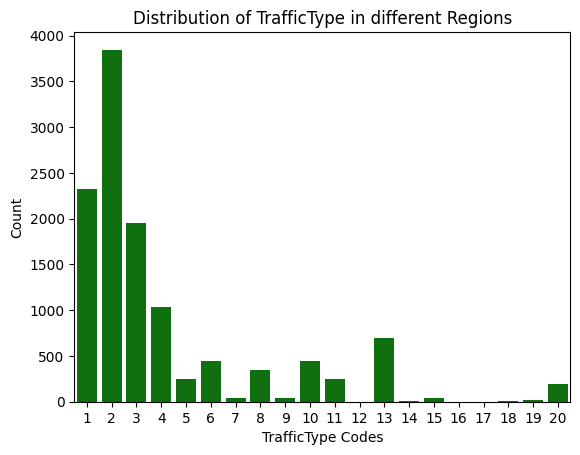

In [19]:
sns.countplot(x=df['TrafficType'], color = 'green')
plt.title('Distribution of TrafficType in different Regions')
plt.xlabel('TrafficType Codes')
plt.ylabel('Count')
plt.show()

In [22]:
#Feature importances

X = df.drop('Revenue', axis=1)
y = df['Revenue']

model = RandomForestClassifier(random_state= 42) #using classifier because revenue is binary, making it a classification problem
model.fit(X,y)

importances = model.feature_importances_

importances_df = pd.DataFrame({
            'feature': X.columns,
            'importance': importances
}).sort_values(by= 'importance', ascending= False)

importances_df

,feature,importance
8,PageValues,0.378634
5,ProductRelated_Duration,0.089455
7,ExitRates,0.089248
4,ProductRelated,0.073608
1,Administrative_Duration,0.056376
6,BounceRates,0.055428
0,Administrative,0.042716
10,Month,0.041938
14,TrafficType,0.031847
13,Region,0.030568


In [23]:
print('Users with high PageValues and low ExitRates are more likely to purchase')

Users with high PageValues and low ExitRates are more likely to purchase


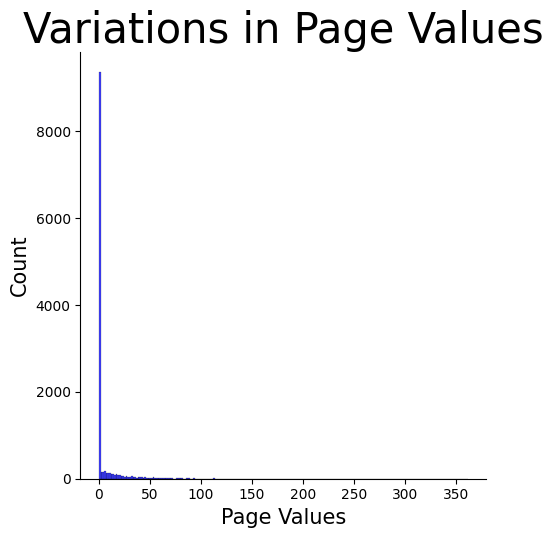

In [24]:
# checking the variations in the page values for the online shoppers

sns.displot(df['PageValues'], color = 'blue')
plt.title('Variations in Page Values', fontsize = 30)
plt.xlabel('Page Values', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.show()

<Axes: xlabel='Revenue', ylabel='PageValues'>

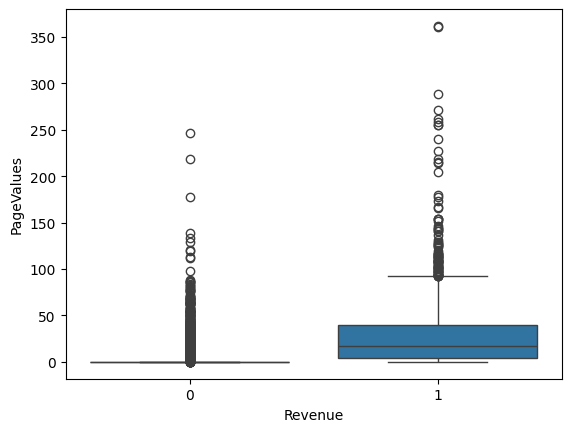

In [25]:
#relationship between page values and revenue

sns.boxplot(x='Revenue', y='PageValues', data=df)

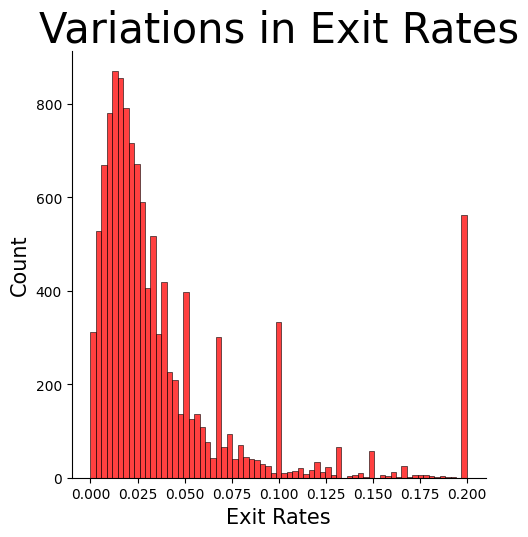

In [26]:
#variations in exit rates
sns.displot(df['ExitRates'], color = 'red')
plt.title('Variations in Exit Rates', fontsize = 30)
plt.xlabel('Exit Rates', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.show()

<Axes: xlabel='Revenue', ylabel='ExitRates'>

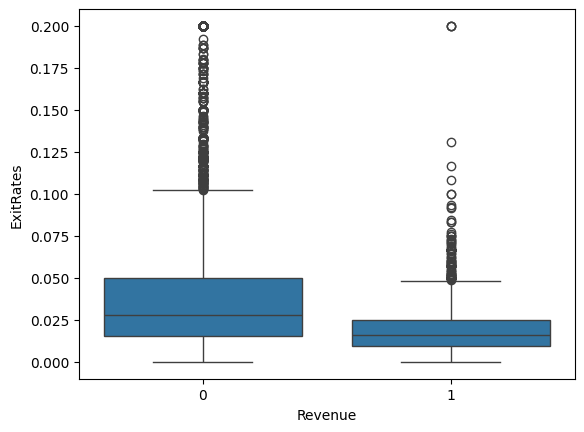

In [27]:
#relationship between exitrates and revenue
sns.boxplot(x='Revenue', y='ExitRates', data=df)

In [28]:
#splitting data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y) #for the imbalanced data

print("Shape of x_train :", X_train.shape)
print("Shape of y_train :", y_train.shape)
print("Shape of x_test :", X_test.shape)
print("Shape of y_test :", y_test.shape)

Shape of x_train : (9536, 19)
Shape of y_train : (9536,)
Shape of x_test : (2384, 19)
Shape of y_test : (2384,)


#### Logistic Model Training

In [29]:
#Start with a baseline so I can compare the models 
logistic_model_baseline = Pipeline([
    ('scaler', StandardScaler() ),
    ('model', LogisticRegression(max_iter= 1000))
])

logistic_model_baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [30]:
# Baseline predictions
y_train_pred = logistic_model_baseline.predict(X_train)
y_test_pred = logistic_model_baseline.predict(X_test)
y_test_prob = logistic_model_baseline.predict_proba(X_test)[:, 1]

print('Baseline Train accuracy:')
print(accuracy_score(y_train, y_train_pred))
print('Baseline Test accuracy:')
print(accuracy_score(y_test, y_test_pred))
print('Baseline Precision:')
print(precision_score(y_test, y_test_pred))
print('Baseline Recall:')
print(recall_score(y_test, y_test_pred))
print('Baseline ROC-AUC:')
print(roc_auc_score(y_test, y_test_prob))
print("\nBaseline Classification Report:\n", classification_report(y_test, y_test_pred))

Baseline Train accuracy:
0.8799286912751678
Baseline Test accuracy:
0.8884228187919463
Baseline Precision:
0.7644230769230769
Baseline Recall:
0.4228723404255319
Baseline ROC-AUC:
0.8875720522166652

Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      2008
           1       0.76      0.42      0.54       376

    accuracy                           0.89      2384
   macro avg       0.83      0.70      0.74      2384
weighted avg       0.88      0.89      0.87      2384



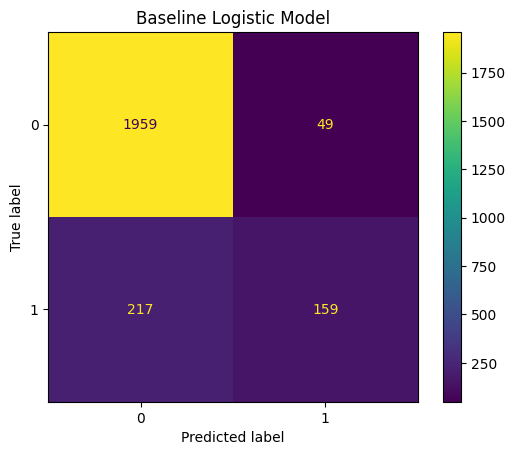

In [31]:
cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.title('Baseline Logistic Model')
plt.show() 

***Now trying logistic model with hypertuning parameters***

In [32]:
#With hypertuning 

param_dist = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced'], #model cares more about buyers (class 1)
    'model__max_iter': [500, 1000, 2000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_log = RandomizedSearchCV(
    estimator=logistic_model_baseline,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_log.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__max_iter': [500, 1000, ...], 'model__solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [33]:
print("Best params:", random_search_log.best_params_)
print("Best CV ROC-AUC:", random_search_log.best_score_)

Best params: {'model__solver': 'liblinear', 'model__max_iter': 500, 'model__class_weight': 'balanced', 'model__C': 10}
Best CV ROC-AUC: 0.8968319005281271


In [34]:
#Evaluating again on the test set
y_pred = random_search_log.predict(X_test)
y_prob = random_search_log.predict_proba(X_test)[:, 1]

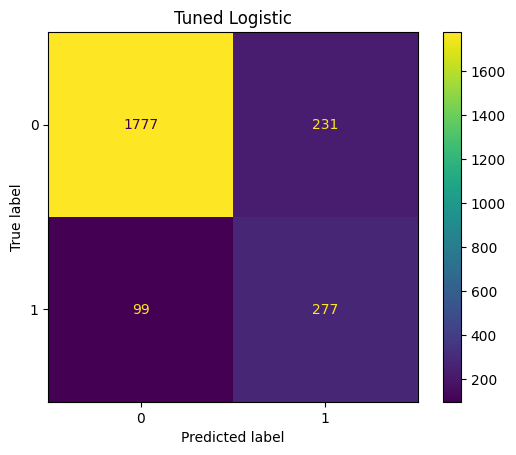

In [35]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.title('Tuned Logistic')
plt.show() 

In [36]:
#Metrics 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob)) #overall model quality

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8615771812080537
Precision: 0.5452755905511811
Recall: 0.7367021276595744
ROC-AUC: 0.898671272357379

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.92      2008
           1       0.55      0.74      0.63       376

    accuracy                           0.86      2384
   macro avg       0.75      0.81      0.77      2384
weighted avg       0.88      0.86      0.87      2384



In [37]:
print("Comparison:")
print("Baseline ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("Tuned ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Baseline Recall:", recall_score(y_test, y_test_pred))
print("Tuned Recall:", recall_score(y_test, y_pred))
print("Baseline Precision:", precision_score(y_test, y_test_pred))
print("Tuned Precision:", precision_score(y_test, y_pred))

print("\nOverall the tuned logistic model performed much better than the baseline.")

Comparison:
Baseline ROC-AUC: 0.8875720522166652
Tuned ROC-AUC: 0.898671272357379
Baseline Recall: 0.4228723404255319
Tuned Recall: 0.7367021276595744
Baseline Precision: 0.7644230769230769
Tuned Precision: 0.5452755905511811

Overall the tuned logistic model performed much better than the baseline.


***Random Forest***

In [38]:
#Random Forest baseline

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

#predictions
rf_train_pred = rf_baseline.predict(X_train)
rf_test_pred = rf_baseline.predict(X_test)
rf_test_prob = rf_baseline.predict_proba(X_test)[:,1]

#Metrics
print('Baseline Train accuracy:')
print(accuracy_score(y_train, rf_train_pred))
print('Baseline Test accuracy:')
print(accuracy_score(y_test, rf_test_pred))
print('Baseline Precision:')
print(precision_score(y_test, rf_test_pred))
print('Baseline Recall:')
print(recall_score(y_test, rf_test_pred))
print('Baseline ROC-AUC:')
print(roc_auc_score(y_test, rf_test_prob))
print("\nBaseline Classification Report:\n", classification_report(y_test, rf_test_pred))

Baseline Train accuracy:
0.9998951342281879
Baseline Test accuracy:
0.9014261744966443
Baseline Precision:
0.7357859531772575
Baseline Recall:
0.5851063829787234
Baseline ROC-AUC:
0.9285702932949055

Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      2008
           1       0.74      0.59      0.65       376

    accuracy                           0.90      2384
   macro avg       0.83      0.77      0.80      2384
weighted avg       0.90      0.90      0.90      2384



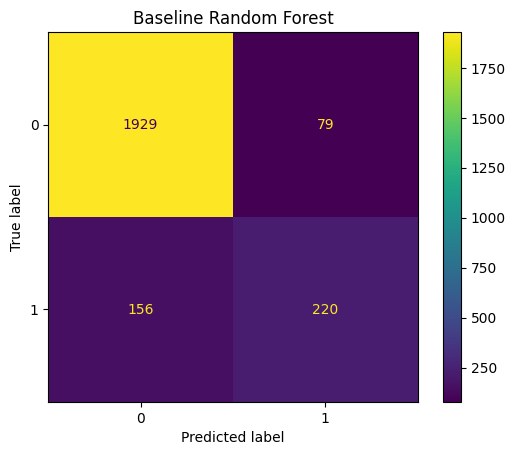

In [39]:
# Confusion matrix
cm = confusion_matrix(y_test, rf_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.title("Baseline Random Forest")
plt.show()

In [40]:
#Lets try with hypertuning now
rf_classifier = RandomForestClassifier(random_state=42)

param_grid = {
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


rf_random_search = RandomizedSearchCV(
    estimator= rf_classifier,
    param_distributions= param_grid,
    cv=cv,
    n_jobs= -1,
    verbose= 2, 
    random_state= 42,
    n_iter= 20,
    scoring = 'roc_auc'

)

rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END class_weight=balanced, criterion=entropy, max_depth=5, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END class_weight=None, criterion=gini, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END class_weight=None, criterion=gini, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   0.5s
[CV] END class_weight=None, criterion=gini, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   0

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [41]:
print("Best params:", rf_random_search.best_params_)
print("Best Score:", rf_random_search.best_score_)

Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced'}
Best Score: 0.9275370830701183


In [42]:
#Evaluating on the test set
tuned_y_pred = rf_random_search.predict(X_test)
tuned_y_prob = rf_random_search.predict_proba(X_test)[:, 1]

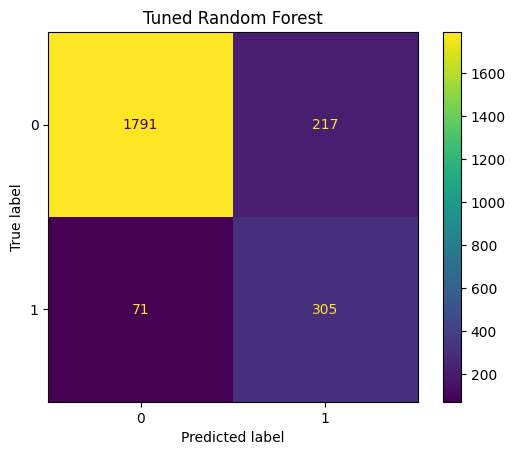

In [43]:
cm = confusion_matrix(y_true=y_test, y_pred=tuned_y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

cm_display.plot()
plt.title("Tuned Random Forest")
plt.show()


In [44]:
# Metrics
print("Accuracy:", accuracy_score(y_test, tuned_y_pred))
print("Precision:", precision_score(y_test, tuned_y_pred))
print("Recall:", recall_score(y_test, tuned_y_pred))
print("ROC-AUC:", roc_auc_score(y_test, tuned_y_prob))

print("\nClassification Report:\n", classification_report(y_test, tuned_y_pred))


Accuracy: 0.8791946308724832
Precision: 0.5842911877394636
Recall: 0.8111702127659575
ROC-AUC: 0.9342351339323556

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.93      2008
           1       0.58      0.81      0.68       376

    accuracy                           0.88      2384
   macro avg       0.77      0.85      0.80      2384
weighted avg       0.90      0.88      0.89      2384



In [45]:
# Comparison
print("Comparison:")
print("Baseline Accuracy:", accuracy_score(y_test, rf_test_pred))
print("Tuned Accuracy:", accuracy_score(y_test, tuned_y_pred))

print("Baseline ROC-AUC:", roc_auc_score(y_test, rf_test_prob))
print("Tuned ROC-AUC:", roc_auc_score(y_test, tuned_y_prob))

print("Baseline Recall:", recall_score(y_test, rf_test_pred))
print("Tuned Recall:", recall_score(y_test, tuned_y_pred))

print("Baseline Precision:", precision_score(y_test, rf_test_pred))
print("Tuned Precision:", precision_score(y_test, tuned_y_pred))

Comparison:
Baseline Accuracy: 0.9014261744966443
Tuned Accuracy: 0.8791946308724832
Baseline ROC-AUC: 0.9285702932949055
Tuned ROC-AUC: 0.9342351339323556
Baseline Recall: 0.5851063829787234
Tuned Recall: 0.8111702127659575
Baseline Precision: 0.7357859531772575
Tuned Precision: 0.5842911877394636


***Our tuned Random Forest did perform better with huge improvement on recall from 58% buyers to 81%. But on accuracy it slightly went down, but that is not bad at all. Since our baseline accuracy predicts mostly 0 and gets high accuracy 'for free'. On the other hand our tuned model predicts more 1s (buyers) and makes more mistakes on class 0, which makes the accuracy drop. The model has higher recall, meaning it captures most buyers, but at the cost of more false positives. This may lead to unnecessary marketing costs. Since our overall roc auc improved which gives the model better overall quality, the tuned model is much better.***

***XG BOOST***

In [46]:
# Baseline XGBoost

xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train, y_train)

# Predictions
xgb_train_pred = xgb_baseline.predict(X_train)
xgb_test_pred = xgb_baseline.predict(X_test)
xgb_test_prob = xgb_baseline.predict_proba(X_test)[:, 1]

# Metrics
print("Baseline Train Accuracy")
print(accuracy_score(y_train, xgb_train_pred))
print('Baseline Test accuracy:')
print(accuracy_score(y_test, xgb_test_pred))
print('Baseline Precision:')
print(precision_score(y_test, xgb_test_pred))
print('Baseline Recall:')
print(recall_score(y_test, xgb_test_pred))
print('Baseline ROC-AUC:')
print(roc_auc_score(y_test, xgb_test_prob))
print("\nBaseline Classification Report:\n", classification_report(y_test, xgb_test_pred))


Baseline Train Accuracy
0.9853187919463087
Baseline Test accuracy:
0.8968120805369127
Baseline Precision:
0.6993865030674846
Baseline Recall:
0.6063829787234043
Baseline ROC-AUC:
0.9320722429431211

Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      2008
           1       0.70      0.61      0.65       376

    accuracy                           0.90      2384
   macro avg       0.81      0.78      0.79      2384
weighted avg       0.89      0.90      0.89      2384



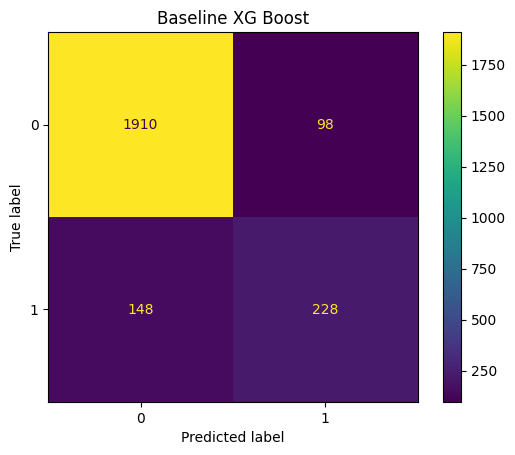

In [47]:
# Confusion matrix
cm = confusion_matrix(y_test, xgb_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.title("Baseline XG Boost")
plt.show()

In [48]:
# XGBoost with a stronger starting configuration before tuning

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [49]:
#hyperparameter tuning
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [50]:
#run tuning
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [51]:
#Best model
best_xgb = random_search.best_estimator_
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 5, 'colsample_bytree': 0.7}


In [52]:
#Evaluate on the test set
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC: 0.9374622520556073

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      2008
           1       0.73      0.61      0.67       376

    accuracy                           0.90      2384
   macro avg       0.83      0.79      0.81      2384
weighted avg       0.90      0.90      0.90      2384



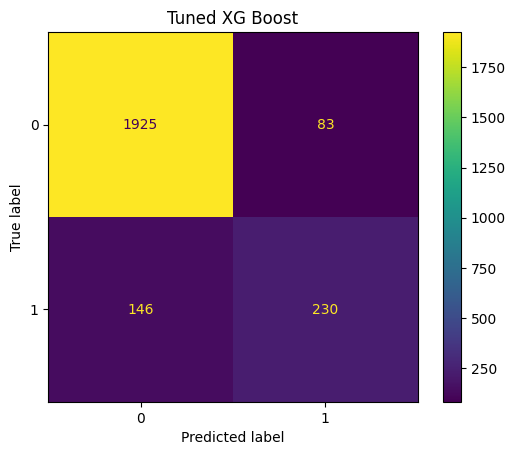

In [53]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.title('Tuned XG Boost')
plt.show() 

In [54]:
# Comparison
print("Comparison:")
print("Baseline Accuracy:", accuracy_score(y_test, xgb_test_pred))
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

print("Baseline ROC-AUC:", roc_auc_score(y_test, xgb_test_prob))
print("Tuned ROC-AUC:", roc_auc_score(y_test, y_prob))

print("Baseline Recall:", recall_score(y_test, xgb_test_pred))
print("Tuned Recall:", recall_score(y_test, y_pred))

print("Baseline Precision:", precision_score(y_test, xgb_test_pred))
print("Tuned Precision:", precision_score(y_test, y_pred))

print("\nOverall the tuned XG Boost model performed much better than the baseline.")

Comparison:
Baseline Accuracy: 0.8968120805369127
Tuned Accuracy: 0.9039429530201343
Baseline ROC-AUC: 0.9320722429431211
Tuned ROC-AUC: 0.9374622520556073
Baseline Recall: 0.6063829787234043
Tuned Recall: 0.6117021276595744
Baseline Precision: 0.6993865030674846
Tuned Precision: 0.7348242811501597

Overall the tuned XG Boost model performed much better than the baseline.


***GRADIENT BOOSTING***

In [56]:
# Baseline

gb_baseline = GradientBoostingClassifier(random_state=42)

gb_baseline.fit(X_train, y_train)

# Predictions
gb_train_pred = gb_baseline.predict(X_train)
gb_test_pred = gb_baseline.predict(X_test)
gb_test_prob = gb_baseline.predict_proba(X_test)[:, 1]

# Metrics
print("Baseline Train Accuracy")
print(accuracy_score(y_train, gb_train_pred))
print('Baseline Test accuracy:')
print(accuracy_score(y_test, gb_test_pred))
print('Baseline Precision:')
print(precision_score(y_test, gb_test_pred))
print('Baseline Recall:')
print(recall_score(y_test, gb_test_pred))
print('Baseline ROC-AUC:')
print(roc_auc_score(y_test, gb_test_prob))
print("\nBaseline Classification Report:\n", classification_report(y_test, gb_test_pred))


Baseline Train Accuracy
0.9183095637583892
Baseline Test accuracy:
0.902265100671141
Baseline Precision:
0.7284345047923323
Baseline Recall:
0.6063829787234043
Baseline ROC-AUC:
0.9350477081037551

Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      2008
           1       0.73      0.61      0.66       376

    accuracy                           0.90      2384
   macro avg       0.83      0.78      0.80      2384
weighted avg       0.90      0.90      0.90      2384



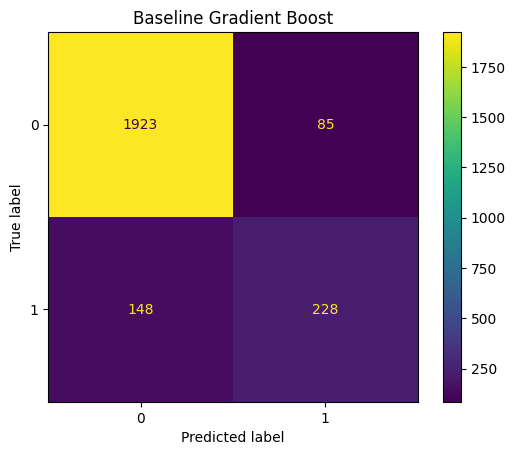

In [57]:
# Confusion matrix
cm = confusion_matrix(y_test, gb_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.title("Baseline Gradient Boost")
plt.show()

In [58]:
#Now with hyper tuning
gradient_boost = GradientBoostingClassifier(random_state=42)

gradient_boost.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [59]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}


In [60]:
#run tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_gb = RandomizedSearchCV(
    estimator=gradient_boost,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

tuned_gb.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [61]:
#Best model
best_gradient = tuned_gb.best_estimator_
print(tuned_gb.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.05}


In [62]:
# Evaluate on the test set
y_pred = best_gradient.predict(X_test)
y_prob = best_gradient.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC-AUC: 0.9349179081546157

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      2008
           1       0.71      0.60      0.65       376

    accuracy                           0.90      2384
   macro avg       0.82      0.78      0.80      2384
weighted avg       0.89      0.90      0.90      2384



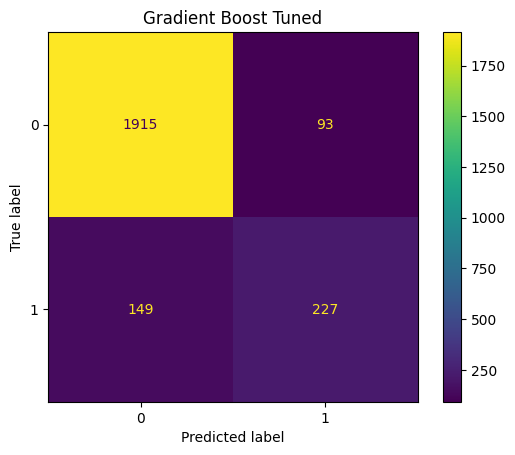

In [63]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.title('Gradient Boost Tuned')
plt.show() 

In [64]:
#comparison
print("Comparison:")
print("Baseline Accuracy:", accuracy_score(y_test, gb_test_pred))
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

print("Baseline ROC-AUC:", roc_auc_score(y_test, gb_test_prob))
print("Tuned ROC-AUC:", roc_auc_score(y_test, y_prob))

print("Baseline Recall:", recall_score(y_test, gb_test_pred))
print("Tuned Recall:", recall_score(y_test, y_pred))

print("Baseline Precision:", precision_score(y_test, gb_test_pred))
print("Tuned Precision:", precision_score(y_test, y_pred))

Comparison:
Baseline Accuracy: 0.902265100671141
Tuned Accuracy: 0.8984899328859061
Baseline ROC-AUC: 0.9350477081037551
Tuned ROC-AUC: 0.9349179081546157
Baseline Recall: 0.6063829787234043
Tuned Recall: 0.6037234042553191
Baseline Precision: 0.7284345047923323
Tuned Precision: 0.709375


***Comparsion of all the models***

In [65]:
#comparing models 

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }

In [66]:
results = []

results.append(evaluate_model("LogReg Base", logistic_model_baseline, X_test, y_test))
results.append(evaluate_model("LogReg Tuned", random_search_log, X_test, y_test))
results.append(evaluate_model("RF Base", rf_baseline, X_test, y_test))
results.append(evaluate_model("RF Tuned", rf_random_search, X_test, y_test))
results.append(evaluate_model("XGB Baseline", xgb_baseline, X_test, y_test))
results.append(evaluate_model("XGB Tuned", best_xgb, X_test, y_test))
results.append(evaluate_model("GB Baseline", gb_baseline, X_test, y_test))
results.append(evaluate_model("GB Tuned", tuned_gb, X_test, y_test))

In [67]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print(results_df)

          Model   ROC-AUC    Recall  Precision        F1
5     XGB Tuned  0.937462  0.611702   0.734824  0.667634
6   GB Baseline  0.935048  0.606383   0.728435  0.661829
7      GB Tuned  0.934918  0.603723   0.709375  0.652299
3      RF Tuned  0.934235  0.811170   0.584291  0.679287
4  XGB Baseline  0.932072  0.606383   0.699387  0.649573
2       RF Base  0.928570  0.585106   0.735786  0.651852
1  LogReg Tuned  0.898671  0.736702   0.545276  0.626697
0   LogReg Base  0.887572  0.422872   0.764423  0.544521


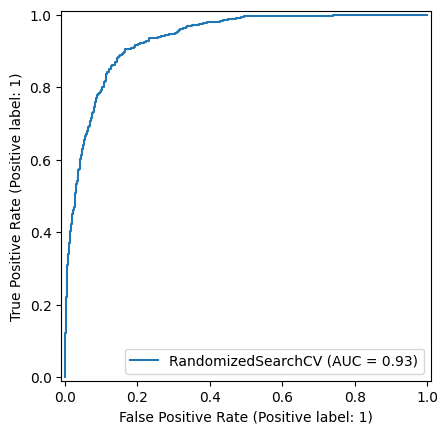

In [68]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf_random_search, X_test, y_test)

When working on this dataset, my goal was not just to find the model with the highest accuracy, but to find the model that best supports the business goal of predicting which users will actually make a purchase.

The first thing I noticed was that the data is unbalanced, with about 15% of users making a purchase. Therefore, I chose to focus on metrics such as ROC-AUC, recall, and precision instead of accuracy, since accuracy can be misleading in this type of problem.

I tested several models: logistic regression, Random Forest, Gradient Boosting, and XGBoost, both as a baseline and after hyperparameter tuning.

When I compared the results, I saw that the tuned Random Forest model performed best in terms of ROC-AUC, with a value around 0.93. It also had the highest recall, around 78%, which means it is the best at identifying users who will actually make a purchase.

At the same time, there is a clear trade off. The precision of the Random Forest was lower, around 60%, which means that the model also produces more false positives. On the other hand, Gradient Boosting and XGBoost had slightly lower recall but higher precision, which makes them more balanced.

The logistic regression clearly improved after tuning, especially when I used class weights, but it still did not reach the same level as the tree based models. This is likely because it assumes linear relationships, while this type of data contains more complex patterns.

My conclusion is therefore that there is no single “best” model, the choice depends on the business goal. If the goal is to capture as many potential customers as possible, I would choose the tuned Random Forest model. If the goal is instead to reduce the number of false positives and be more accurate, then Gradient Boosting or XGBoost are better options.